In [8]:
import os, warnings, random, shutil
import numpy as np
import pandas as pd
import cv2
from PIL import Image
from collections import Counter
from tqdm import tqdm
from joblib import Parallel, delayed

import torch
from torch.utils.data import Dataset, WeightedRandomSampler
import torchvision.transforms as transforms

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight


In [13]:
# =============================================================================
# CONFIG
# =============================================================================
SEED             = 42
TEST_SIZE        = 0.15
VAL_SIZE         = 0.15
IMAGE_SIZE       = (28, 28)
N_JOBS           = -1

AUG_ANGLE        = 10
AUG_SHIFT        = 2
AUG_SCALE        = (0.9, 1.1)
TRAIN_TRANSLATE  = (0.1, 0.1)

QUALITY_STD_MIN  = 5
QUALITY_MEAN_MIN = 10
QUALITY_MEAN_MAX = 245

# ===== BALANCING STRATEGY =====
# Target samples per class for math symbols
# RECOMMENDED: 3000-5000 for optimal balance with EMNIST
TARGET_PER_CLASS = 5000  # Options: 3000 (fast), 4000 (recommended), 5000 (more data)
# ==============================
EMNIST_DOWNSAMPLE = True  # Add this!
EMNIST_TARGET_PER_CLASS = 5000  # Add this!

BASE_DIR          = r'C:\Users\User\kelompok2'
EMNIST_TRAIN_CSV  = os.path.join(BASE_DIR, 'emnist', 'emnist-byclass-train.csv')
EMNIST_TEST_CSV   = os.path.join(BASE_DIR, 'emnist', 'emnist-byclass-test.csv')
MATH_SYMBOLS_DIR  = os.path.join(BASE_DIR, 'mathSymbols', 'data', 'extracted_images')
MATH_AUG_SAVE_DIR = os.path.join(BASE_DIR, 'mathSymbolsAugmented')
OUTPUT_DIR        = os.path.join(BASE_DIR, 'outputs')
# =============================================================================

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

os.makedirs(OUTPUT_DIR, exist_ok=True)
for p in [EMNIST_TRAIN_CSV, EMNIST_TEST_CSV, MATH_SYMBOLS_DIR]:
    assert os.path.exists(p), f"Not found: {p}"

print(f"Device: {device}" + (f" | GPU: {torch.cuda.get_device_name(0)}" if torch.cuda.is_available() else ""))
print("All paths verified")

Device: cpu
All paths verified



[1/8] Loading EMNIST (Memory Optimized)...
  Reading from: C:\Users\User\kelompok2\emnist\emnist-byclass-train.csv ...
  Original Size : 814,255 samples
  ✂️  Downsampling to max 5000 per class...
  Balanced Size : 266,475 samples
  🎨 Inverting colors (255 - pixel)...
  Final Samples : 266,475
  Classes       : 62


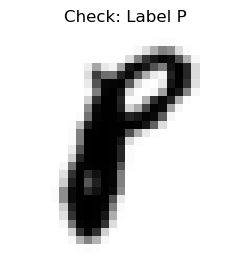

In [2]:
# =============================================================================
# STEP 1: Load EMNIST, Downsample & Invert Colors (MEMORY OPTIMIZED & STANDALONE)
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import gc # Garbage Collector

# --- KONFIGURASI ULANG (Agar tidak NameError setelah restart kernel) ---
# Pastikan path ini sesuai dengan struktur foldermu
BASE_DIR = r'C:\Users\User\kelompok2' 
EMNIST_TRAIN_CSV = os.path.join(BASE_DIR, 'emnist', 'emnist-byclass-train.csv')
EMNIST_TEST_CSV  = os.path.join(BASE_DIR, 'emnist', 'emnist-byclass-test.csv')
SEED = 42
IMAGE_SIZE = (28, 28)
# -----------------------------------------------------------------------

print("\n[1/8] Loading EMNIST (Memory Optimized)...")

# 1. Load CSV dengan tipe data 'uint8' (1 byte) bukan 'int64' (8 bytes)
print(f"  Reading from: {EMNIST_TRAIN_CSV} ...")
# Pastikan file ada
if not os.path.exists(EMNIST_TRAIN_CSV):
    raise FileNotFoundError(f"File tidak ditemukan: {EMNIST_TRAIN_CSV}")

df_train = pd.read_csv(EMNIST_TRAIN_CSV, header=None, dtype=np.uint8)
df_test  = pd.read_csv(EMNIST_TEST_CSV,  header=None, dtype=np.uint8)
emnist_df = pd.concat([df_train, df_test], ignore_index=True)

# Hapus variabel lama dari RAM segera
del df_train, df_test
gc.collect() 

print(f"  Original Size : {len(emnist_df):,} samples")

# 2. --- DOWNSAMPLING (Maksimal 5000 per kelas) ---
TARGET_COUNT = 5000
print(f"  ✂️  Downsampling to max {TARGET_COUNT} per class...")

# Group by label (kolom 0) dan ambil sampel
groups = emnist_df.groupby(0)
sampled_list = []

for label, group in groups:
    if len(group) > TARGET_COUNT:
        sampled_list.append(group.sample(n=TARGET_COUNT, random_state=SEED))
    else:
        sampled_list.append(group)

# Hapus dataframe besar dari RAM sebelum penggabungan ulang
del emnist_df
gc.collect()

# Gabung ulang dan acak urutannya
emnist_balanced = pd.concat(sampled_list).sample(frac=1, random_state=SEED).reset_index(drop=True)
print(f"  Balanced Size : {len(emnist_balanced):,} samples")

# 3. Ambil Array Gambar & Label
# Kolom 0 adalah label, kolom 1 s.d akhir adalah pixel
raw_images = emnist_balanced.iloc[:, 1:].values # Otomatis uint8
emnist_labels = emnist_balanced.iloc[:, 0].values

# Hapus dataframe balanced dari RAM
del emnist_balanced
gc.collect()

# 4. --- PERBAIKAN WARNA (INVERT) ---
# Ubah Putih-atas-Hitam menjadi Hitam-atas-Putih
print("  🎨 Inverting colors (255 - pixel)...")
emnist_images = 255 - raw_images 
# -----------------------------------

emnist_mapping = {
    **{i:    str(i)       for i in range(10)},
    **{i+10: chr(65+i)    for i in range(26)},
    **{i+36: chr(97+i)    for i in range(26)},
}

# Validasi
assert emnist_images.shape[1] == IMAGE_SIZE[0] * IMAGE_SIZE[1], \
    f"Mismatch dimensions: {emnist_images.shape[1]}"
assert len(emnist_images) == len(emnist_labels), "Count mismatch"

print(f"  Final Samples : {len(emnist_images):,}")
print(f"  Classes       : {len(emnist_mapping)}")

# Preview untuk memastikan
plt.figure(figsize=(3,3))
# Transpose agar tegak (karena EMNIST aslinya miring)
plt.imshow(emnist_images[0].reshape(28,28).T, cmap='gray') 
plt.title(f"Check: Label {emnist_mapping[emnist_labels[0]]}")
plt.axis('off')
plt.show()

In [4]:
# =============================================================================
# STEP 2: Load Math Symbols (STANDALONE VERSION)
# =============================================================================
import os
import cv2
import numpy as np
from joblib import Parallel, delayed
from tqdm import tqdm

# --- KONFIGURASI ULANG (Agar tidak error setelah restart) ---
BASE_DIR = r'C:\Users\User\kelompok2'
MATH_SYMBOLS_DIR = os.path.join(BASE_DIR, 'mathSymbols', 'data', 'extracted_images')
IMAGE_SIZE = (28, 28)
N_JOBS = -1  # Gunakan semua core CPU
# ------------------------------------------------------------

print("\n[2/8] Loading math symbols...")

# Pastikan folder ada
if not os.path.exists(MATH_SYMBOLS_DIR):
    raise FileNotFoundError(f"Folder tidak ditemukan: {MATH_SYMBOLS_DIR}")

subfolders = sorted(f.name for f in os.scandir(MATH_SYMBOLS_DIR) if f.is_dir())
assert len(subfolders) > 0, f"No subfolders found in {MATH_SYMBOLS_DIR}"

math_mapping_raw = {i: name for i, name in enumerate(subfolders)}

tasks = [
    (entry.path, idx)
    for idx, name in enumerate(subfolders)
    for entry in os.scandir(os.path.join(MATH_SYMBOLS_DIR, name))
    if entry.is_file() and entry.name.lower().endswith(('.png', '.jpg', '.jpeg'))
]
assert len(tasks) > 0, "No image files found in math symbols directory"

def load_img(task):
    path, label = task
    try:
        # Load grayscale
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None: return None
        
        # Resize ke 28x28
        img = cv2.resize(img, IMAGE_SIZE)
        
        # Flatten jadi 1D array (784 pixel)
        return img.flatten().astype(np.uint8), np.int64(label)
    except Exception:
        return None

# Load paralel biar cepat
results = Parallel(n_jobs=N_JOBS)(delayed(load_img)(t) for t in tqdm(tasks, desc="  Reading"))
valid   = [r for r in results if r is not None]

assert len(valid) > 0, "No math symbol images loaded successfully"

math_images = np.array([r[0] for r in valid], dtype=np.uint8)
math_labels = np.array([r[1] for r in valid], dtype=np.int64)

assert len(math_images) == len(math_labels), "Math image/label count mismatch after load"
print(f"  Loaded  : {len(math_images):,} / {len(tasks)} images")
print(f"  Failed  : {len(tasks) - len(valid)}")


[2/8] Loading math symbols...


  Reading: 100%|██████████| 375974/375974 [02:22<00:00, 2641.21it/s]


  Loaded  : 375,974 / 375974 images
  Failed  : 0


In [6]:
# =============================================================================
# STEP 3: Quality Check (informational only, no removal)
# =============================================================================
import numpy as np

# --- KONFIGURASI STANDAR KUALITAS GAMBAR ---
QUALITY_STD_MIN  = 5    # Standar deviasi minimum (agar gambar tidak flat/kosong)
QUALITY_MEAN_MIN = 10   # Rata-rata pixel minimum (agar tidak terlalu gelap)
QUALITY_MEAN_MAX = 245  # Rata-rata pixel maksimum (agar tidak terlalu putih)
# -------------------------------------------

print("\n[3/8] Quality check (informational)...")

# Pastikan math_images ada (hasil dari Step 2)
if 'math_images' not in locals():
    raise NameError("Variabel 'math_images' tidak ditemukan. Pastikan Step 2 sudah dijalankan dengan sukses!")

imgs_f      = math_images.astype(np.float32)
low_quality = (
    (np.std(imgs_f, axis=1)  <= QUALITY_STD_MIN)  |
    (np.mean(imgs_f, axis=1) <= QUALITY_MEAN_MIN) |
    (np.mean(imgs_f, axis=1) >= QUALITY_MEAN_MAX)
)

print(f"  Low-quality detected : {low_quality.sum():,} (kept)")
print(f"  Total                : {len(math_images):,}")


[3/8] Quality check (informational)...
  Low-quality detected : 137,452 (kept)
  Total                : 375,974


In [7]:
# =============================================================================
# STEP 4: Remove Digit Classes (already covered by EMNIST)
# =============================================================================
print("\n[4/8] Removing digit classes from math symbols...")
digits     = {str(i) for i in range(10)}
remove_ids = {k for k, v in math_mapping_raw.items() if v in digits}
keep       = ~np.isin(math_labels, list(remove_ids))
n_before   = len(math_images)
math_images, math_labels = math_images[keep], math_labels[keep]

assert len(math_images) == len(math_labels), "Image/label count mismatch after digit removal"
assert len(math_images) > 0, "All math images removed after digit filter"
print(f"  Removed classes : {sorted(math_mapping_raw[k] for k in remove_ids)}")
print(f"  Removed samples : {n_before - len(math_images):,}")
print(f"  Remaining       : {len(math_images):,}")


[4/8] Removing digit classes from math symbols...
  Removed classes : ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
  Removed samples : 94,257
  Remaining       : 281,717


In [9]:
# =============================================================================
# STEP 5: Remap Labels to 0..N-1 (FIXED IMPORT)
# =============================================================================
import numpy as np
from collections import Counter # Tambahkan ini

print("\n[5/8] Remapping math labels...")

# Pastikan math_labels dan math_mapping_raw ada (dari Step 2)
if 'math_labels' not in locals() or 'math_mapping_raw' not in locals():
    raise NameError("Variabel dari Step 2 hilang. Pastikan Step 2 sudah dijalankan!")

unique_old   = sorted(np.unique(math_labels))
math_mapping = {new: math_mapping_raw[old] for new, old in enumerate(unique_old)}
old_to_new   = {old: new for new, old in enumerate(unique_old)}
math_labels  = np.array([old_to_new[l] for l in math_labels], dtype=np.int64)

assert math_labels.min() == 0, "Remapped labels do not start at 0"
assert math_labels.max() == len(math_mapping) - 1, "Remapped labels do not end at N-1"
assert len(np.unique(math_labels)) == len(math_mapping), "Label count mismatch after remap"

counts  = Counter(math_labels.tolist())
vals    = list(counts.values())
print(f"  Classes         : {len(math_mapping)}")
print(f"  Imbalance ratio : {max(vals)/min(vals):.1f}x | min={min(vals)} max={max(vals)}")


[5/8] Remapping math labels...
  Classes         : 72
  Imbalance ratio : 1618.9x | min=21 max=33997


In [11]:
# =============================================================================
# STEP 6: Balance via Capped Oversampling + Augmentation (STANDALONE FIX)
# =============================================================================
import os
import numpy as np
import cv2
import shutil
from collections import Counter
from tqdm import tqdm

# --- KONFIGURASI ULANG (Agar tidak error NameError) ---
BASE_DIR = r'C:\Users\User\kelompok2'
OUTPUT_DIR = os.path.join(BASE_DIR, 'outputs')
IMAGE_SIZE = (28, 28)
AUG_ANGLE = 10
AUG_SHIFT = 2
TARGET_PER_CLASS = 5000  # Target jumlah data per kelas
# ------------------------------------------------------

print("\n[6/8] Balancing dataset (disk-backed)...")

# Pastikan folder output ada
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Pastikan data dari Step sebelumnya ada di memori
if 'math_images' not in locals() or 'math_labels' not in locals():
    raise NameError("Data 'math_images' atau 'math_labels' tidak ditemukan. Pastikan Step 1-5 sudah dijalankan!")

def augment_batch(imgs: np.ndarray) -> np.ndarray:
    n         = len(imgs)
    imgs2d    = imgs.reshape(n, *IMAGE_SIZE).astype(np.float32)
    angles    = np.random.uniform(-AUG_ANGLE, AUG_ANGLE, n)
    shifts    = np.random.uniform(-AUG_SHIFT, AUG_SHIFT, (n, 2)).astype(np.float32)
    cx, cy    = IMAGE_SIZE[0] / 2, IMAGE_SIZE[1] / 2
    out       = np.empty((n, *IMAGE_SIZE), dtype=np.uint8)
    for i in range(n):
        cos_a, sin_a = np.cos(np.radians(angles[i])), np.sin(np.radians(angles[i]))
        M  = np.array([[cos_a, sin_a, (1-cos_a)*cx - sin_a*cy],
                       [-sin_a, cos_a, sin_a*cx + (1-cos_a)*cy]], dtype=np.float32)
        M[0, 2] += shifts[i, 0]
        M[1, 2] += shifts[i, 1]
        out[i] = cv2.warpAffine(imgs2d[i], M, IMAGE_SIZE,
                                flags=cv2.INTER_LINEAR,
                                borderMode=cv2.BORDER_CONSTANT, borderValue=0)
    return out.reshape(n, -1)

counts     = Counter(math_labels.tolist())
vals       = list(counts.values())
global_max = max(vals)
# Use fixed target per class (capped at original max if smaller)
target     = min(TARGET_PER_CLASS, global_max)
total_out  = target * len(math_mapping)
flat_size  = IMAGE_SIZE[0] * IMAGE_SIZE[1]
BATCH_SIZE = 512

print(f"  Global max       : {global_max:,}")
print(f"  Oversample target: {target:,} per class")
print(f"  Total output     : {total_out:,}")

MMAP_IMG_PATH = os.path.join(OUTPUT_DIR, 'math_bal_images.mmap')
MMAP_LBL_PATH = os.path.join(OUTPUT_DIR, 'math_bal_labels.mmap')

# Hapus file mmap lama jika ada
for p in [MMAP_IMG_PATH, MMAP_LBL_PATH]:
    if os.path.exists(p): os.remove(p)

mmap_images = np.memmap(MMAP_IMG_PATH, dtype=np.uint8, mode='w+', shape=(total_out, flat_size))
mmap_labels = np.memmap(MMAP_LBL_PATH, dtype=np.int64, mode='w+', shape=(total_out,))

write_ptr = 0
for cls in tqdm(range(len(math_mapping)), desc="  Augmenting"):
    idx    = np.where(math_labels == cls)[0]
    imgs   = math_images[idx]
    n_orig = len(imgs)
    keep   = min(n_orig, target)
    needed = target - keep

    mmap_images[write_ptr:write_ptr + keep] = imgs[:keep]
    mmap_labels[write_ptr:write_ptr + keep] = cls
    write_ptr += keep

    remaining = needed
    while remaining > 0:
        batch    = min(BATCH_SIZE, remaining)
        src_idx  = np.random.randint(0, n_orig, batch)
        augmented = augment_batch(imgs[src_idx])
        mmap_images[write_ptr:write_ptr + batch] = augmented
        mmap_labels[write_ptr:write_ptr + batch] = cls
        write_ptr   += batch
        remaining   -= batch

mmap_images.flush()
mmap_labels.flush()

assert write_ptr == total_out, f"Write pointer {write_ptr} != expected {total_out}"

perm        = np.random.permutation(total_out)
math_images = np.array(mmap_images[perm], dtype=np.uint8)
math_labels = np.array(mmap_labels[perm], dtype=np.int64)

# Bersihkan file mmap dari disk
del mmap_images, mmap_labels
if os.path.exists(MMAP_IMG_PATH): os.remove(MMAP_IMG_PATH)
if os.path.exists(MMAP_LBL_PATH): os.remove(MMAP_LBL_PATH)

assert len(math_images) == len(math_labels), "Image/label count mismatch after augmentation"
assert math_images.dtype == np.uint8, "Augmented images dtype is not uint8"

post_counts = Counter(math_labels.tolist())
assert all(post_counts[c] == target for c in range(len(math_mapping))), \
    "Not all classes reached target count"
print(f"  Final samples    : {len(math_images):,}")
print(f"  Per-class count  : {target:,} (uniform)")


[6/8] Balancing dataset (disk-backed)...
  Global max       : 33,997
  Oversample target: 5,000 per class
  Total output     : 360,000


  Augmenting: 100%|██████████| 72/72 [00:04<00:00, 17.99it/s]


  Final samples    : 360,000
  Per-class count  : 5,000 (uniform)


In [13]:
# =============================================================================
# STEP 7: Save Augmented Images (STANDALONE FIX)
# =============================================================================
import os
import shutil
import numpy as np
import cv2
from joblib import Parallel, delayed
from tqdm import tqdm

# --- KONFIGURASI ULANG ---
BASE_DIR = r'C:\Users\User\kelompok2'
MATH_AUG_SAVE_DIR = os.path.join(BASE_DIR, 'mathSymbolsAugmented')
IMAGE_SIZE = (28, 28)
N_JOBS = -1
# -------------------------

print("\n[7/8] Saving augmented images...")

# Cek apakah data dari Step 6 ada di memori
if 'math_images' not in locals() or 'math_labels' not in locals() or 'math_mapping' not in locals():
    raise NameError("Data (math_images/labels/mapping) hilang. Pastikan Step 2, 5, dan 6 sudah dijalankan berurutan!")

# Bersihkan folder lama jika ada
if os.path.exists(MATH_AUG_SAVE_DIR):
    shutil.rmtree(MATH_AUG_SAVE_DIR)

# Buat folder baru untuk setiap kelas
for name in math_mapping.values():
    os.makedirs(os.path.join(MATH_AUG_SAVE_DIR, name), exist_ok=True)

# Siapkan tugas penyimpanan
label_counters = np.zeros(len(math_mapping), dtype=np.int64)
save_tasks = []

# Zip images dengan labelnya
for img, lbl in zip(math_images, math_labels):
    fname = math_mapping[lbl]
    count = label_counters[lbl]
    path  = os.path.join(MATH_AUG_SAVE_DIR, fname, f"{fname}_{count}.png")
    save_tasks.append((img, path))
    label_counters[lbl] += 1

# Fungsi simpan gambar
def save_img(task):
    img, path = task
    # Reshape jika perlu (flat array -> 2D image)
    if img.ndim == 1:
        img = img.reshape(IMAGE_SIZE)
    cv2.imwrite(path, img)

# Jalankan penyimpanan secara paralel
Parallel(n_jobs=N_JOBS, backend="threading")(
    delayed(save_img)(t) for t in tqdm(save_tasks, desc="  Writing")
)

# Verifikasi jumlah file
saved_total = sum(
    len([f for f in os.listdir(os.path.join(MATH_AUG_SAVE_DIR, name)) if f.endswith('.png')])
    for name in math_mapping.values()
)

print(f"  Saved : {saved_total:,} files -> {MATH_AUG_SAVE_DIR}")

if saved_total != len(math_images):
    print(f"⚠️ WARNING: Saved {saved_total} but expected {len(math_images)}.")
else:
    print("✅ All images saved successfully.")


[7/8] Saving augmented images...


  Writing: 100%|██████████| 360000/360000 [00:55<00:00, 6522.33it/s]


  Saved : 360,000 files -> C:\Users\User\kelompok2\mathSymbolsAugmented
✅ All images saved successfully.


In [16]:
# =============================================================================
# STEP 8: Split & Save to Folders (STANDALONE VERSION)
# =============================================================================
import os
import time
import shutil
import pickle
import cv2
import numpy as np
from joblib import Parallel, delayed
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# --- KONFIGURASI ULANG (Agar tidak error NameError) ---
BASE_DIR = r'C:\Users\User\kelompok2'
OUTPUT_DIR = os.path.join(BASE_DIR, 'outputs')
IMAGE_SIZE = (28, 28)
TEST_SIZE = 0.15
VAL_SIZE = 0.15
SEED = 42
N_JOBS = -1
# ------------------------------------------------------

print("\n[8/8] Splitting and saving to disk (streamed)...")

# Cek apakah data dari Step 1 dan Step 6 ada di memori
if 'emnist_images' not in locals() or 'emnist_labels' not in locals() or \
   'math_images' not in locals() or 'math_labels' not in locals():
    raise NameError("Data EMNIST atau Math tidak ditemukan di memori. \n"
                    "⚠️  PENTING: Pastikan Anda sudah menjalankan Step 1 s.d. Step 7 secara berurutan di sesi ini!")

max_emnist_label = int(emnist_labels.max())

# 1. Mapping dengan nama folder unik
unified_mapping = {k: f"emnist_{v}_{k}" for k, v in emnist_mapping.items()}
unified_mapping.update({i + max_emnist_label + 1: f"math_{v}_{i + max_emnist_label + 1}" for i, v in math_mapping.items()})

assert len(unified_mapping) == len(emnist_mapping) + len(math_mapping), \
    "Unified mapping size mismatch"

# 2. Offset math labels
math_labels_offset = math_labels + max_emnist_label + 1
assert set(np.unique(math_labels_offset)).isdisjoint(set(np.unique(emnist_labels))), \
    "Label spaces overlap after offset"

total_samples = len(emnist_images) + len(math_images)
print(f"  Total samples : {total_samples:,}")
print(f"  Total classes : {len(unified_mapping)}")

# 3. Splitting Indices
def split_indices(labels, test_size, val_size, seed):
    idx      = np.arange(len(labels))
    idx_temp, idx_test = train_test_split(
        idx, test_size=test_size, random_state=seed, stratify=labels)
    idx_train, idx_val = train_test_split(
        idx_temp, test_size=val_size, random_state=seed, stratify=labels[idx_temp])
    return idx_train, idx_val, idx_test

e_train, e_val, e_test = split_indices(emnist_labels,       TEST_SIZE, VAL_SIZE, SEED)
m_train, m_val, m_test = split_indices(math_labels_offset,  TEST_SIZE, VAL_SIZE, SEED)

splits = {
    'train': [(emnist_images, emnist_labels,       e_train),
              (math_images,   math_labels_offset,  m_train)],
    'val':   [(emnist_images, emnist_labels,        e_val),
              (math_images,   math_labels_offset,   m_val)],
    'test':  [(emnist_images, emnist_labels,        e_test),
              (math_images,   math_labels_offset,   m_test)],
}

split_counts = {s: sum(len(idx) for _, _, idx in srcs) for s, srcs in splits.items()}
print(f"  Train : {split_counts['train']:,} | Val : {split_counts['val']:,} | Test : {split_counts['test']:,}")

SPLIT_DIR = os.path.join(OUTPUT_DIR, 'splits')

def save_split(sources, split_name):
    split_root = os.path.join(SPLIT_DIR, split_name)
    
    # Hapus folder lama
    if os.path.exists(split_root):
        shutil.rmtree(split_root)
        time.sleep(1) 
    
    # Buat folder baru
    for cls_name in unified_mapping.values():
        os.makedirs(os.path.join(split_root, cls_name), exist_ok=True)

    counters = {}
    tasks    = []
    for src_id, (images, labels, indices) in enumerate(sources):
        for i in indices:
            lbl      = int(labels[i])
            key      = lbl                              
            cls_name = unified_mapping[lbl]
            count    = counters.get(key, 0)
            
            path     = os.path.join(split_root, cls_name, f"{cls_name}_{count}.png")
            tasks.append((int(i), src_id, path))
            counters[key] = count + 1

    source_arrays = [(images, labels) for images, labels, _ in sources]

    def _save(task):
        i, src_id, path = task
        raw_img = source_arrays[src_id][0][i]
        
        # Reshape
        img = raw_img.reshape(IMAGE_SIZE)
        
        # FIX ROTASI EMNIST (Hanya src_id 0)
        if src_id == 0:
            img = np.transpose(img) 
        
        cv2.imwrite(path, img)

    Parallel(n_jobs=N_JOBS, backend="threading")(
        delayed(_save)(t) for t in tqdm(tasks, desc=f"  Saving {split_name}")
    )

    saved = sum(
        len(os.listdir(os.path.join(split_root, cls_name)))
        for cls_name in unified_mapping.values()
    )
    
    if saved != len(tasks):
        print(f"!! MISMATCH !! Disk: {saved} vs Expected: {len(tasks)}")

    assert saved == len(tasks), \
        f"[{split_name}] Saved {saved} files but expected {len(tasks)}"
    print(f"  [{split_name}] {saved:,} files -> {split_root}")

# Jalankan Save
save_split(splits['train'], 'train')
save_split(splits['val'],   'val')
save_split(splits['test'],  'test')

# Save mapping
mapping_path = os.path.join(OUTPUT_DIR, 'unified_mapping.pkl')
with open(mapping_path, 'wb') as f:
    pickle.dump(unified_mapping, f)
print(f"  Mapping saved -> {mapping_path}")

# Class weights
y_train = np.concatenate([emnist_labels[e_train], math_labels_offset[m_train]])
classes              = np.unique(y_train)
weights              = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_map     = dict(zip(classes.tolist(), weights.tolist()))

print(f"\nDone. Splits saved to: {SPLIT_DIR}")


[8/8] Splitting and saving to disk (streamed)...
  Total samples : 626,475
  Total classes : 134
  Train : 452,627 | Val : 79,876 | Test : 93,972


  Saving train: 100%|██████████| 452627/452627 [01:15<00:00, 5998.75it/s]


  [train] 452,627 files -> C:\Users\User\kelompok2\outputs\splits\train


  Saving val: 100%|██████████| 79876/79876 [00:13<00:00, 6028.33it/s]


  [val] 79,876 files -> C:\Users\User\kelompok2\outputs\splits\val


  Saving test: 100%|██████████| 93972/93972 [00:15<00:00, 6190.49it/s]


  [test] 93,972 files -> C:\Users\User\kelompok2\outputs\splits\test
  Mapping saved -> C:\Users\User\kelompok2\outputs\unified_mapping.pkl

Done. Splits saved to: C:\Users\User\kelompok2\outputs\splits


Analyzing: C:\Users\User\kelompok2\outputs\splits\train ...


100%|██████████| 134/134 [00:03<00:00, 41.85it/s]



DATASET SUMMARY REPORT (TRAIN SPLIT)

1. Image Dimensions Found:
   - 28x28 (1 ch)
   ✅ OK: Semua ukuran gambar seragam.

2. Pixel Value Range:
   - Global Min: 0
   - Global Max: 255
   ✅ OK: Pixel dalam format uint8 (0-255).

3. Class Balance:
   - Total Classes: 134
   - Min Samples: 1599 (emnist_j_45)
   - Max Samples: 3613 (emnist_4_4)
   - Mean Samples: 3377.8


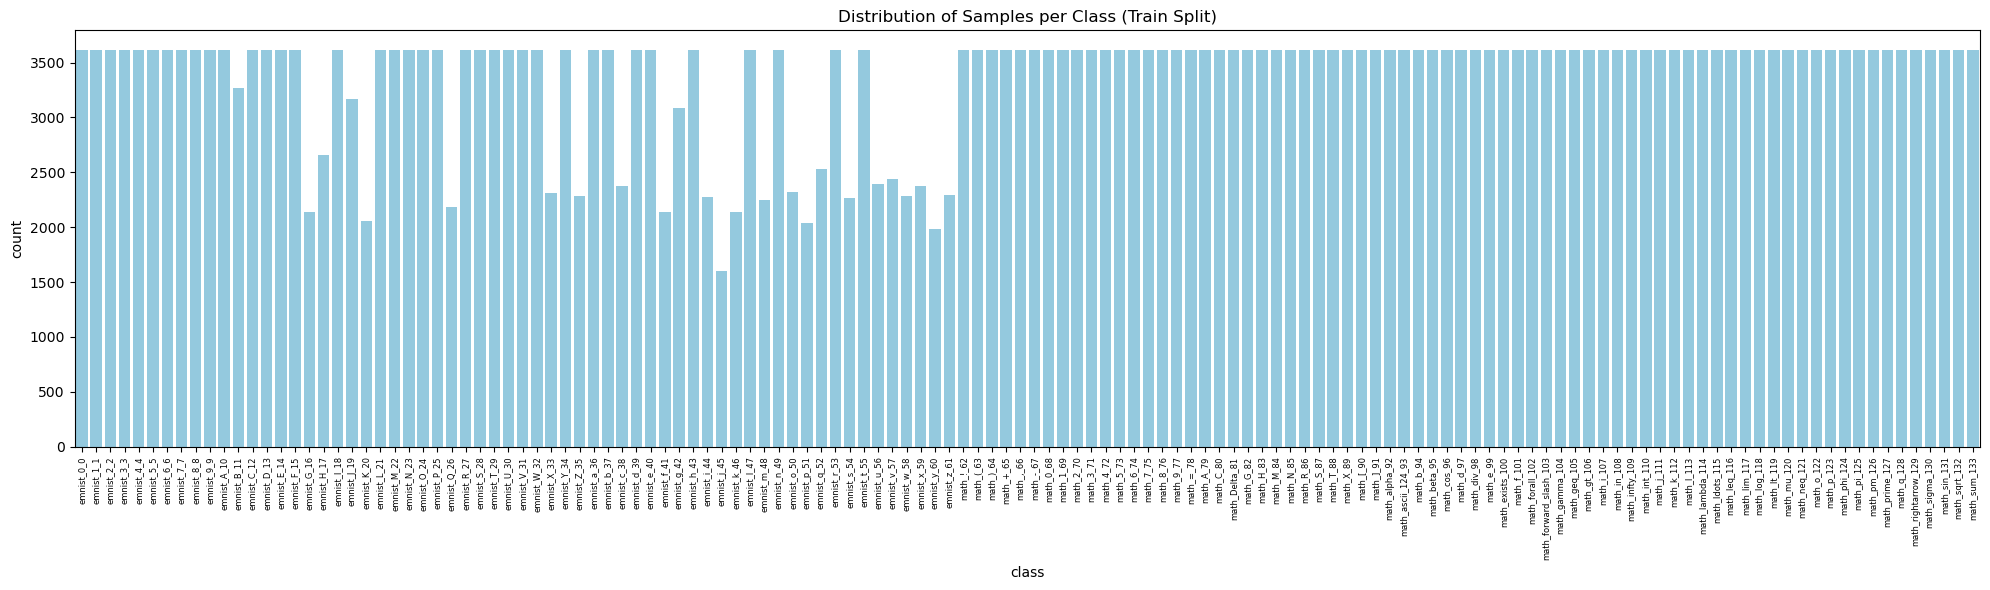


Top 5 Most Common Classes:


,class,count,shape,min_val,max_val
4,emnist_4_4,3613,28x28 (1 ch),0,255
6,emnist_6_6,3613,28x28 (1 ch),0,255
8,emnist_8_8,3613,28x28 (1 ch),0,255
9,emnist_9_9,3613,28x28 (1 ch),0,255
13,emnist_D_13,3613,28x28 (1 ch),0,255



Top 5 Least Common Classes:


,class,count,shape,min_val,max_val
45,emnist_j_45,1599,28x28 (1 ch),0,255
60,emnist_y_60,1984,28x28 (1 ch),0,255
51,emnist_p_51,2035,28x28 (1 ch),0,255
20,emnist_K_20,2059,28x28 (1 ch),0,255
46,emnist_k_46,2136,28x28 (1 ch),0,255


In [17]:
# =============================================================================
# STEP 9: Data Integrity & Distribution Check
# =============================================================================
import os
import cv2
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm

SPLIT_DIR = os.path.join(OUTPUT_DIR, 'splits')

def analyze_dataset(split_dir):
    print(f"Analyzing: {split_dir} ...")
    
    stats = []
    
    # Ambil list semua folder kelas
    classes = sorted(os.listdir(split_dir))
    
    total_files = 0
    inconsistent_shapes = 0
    
    for cls_name in tqdm(classes):
        cls_path = os.path.join(split_dir, cls_name)
        if not os.path.isdir(cls_path):
            continue
            
        files = glob(os.path.join(cls_path, "*.png"))
        count = len(files)
        total_files += count
        
        if count == 0:
            stats.append({
                'class': cls_name, 'count': 0, 
                'shape': 'N/A', 'min_val': 0, 'max_val': 0
            })
            continue
            
        # Cek sampel gambar pertama untuk properti dasar
        # Gunakan IMREAD_UNCHANGED agar kita tahu format aslinya di disk (1 atau 3 channel)
        sample_img = cv2.imread(files[0], cv2.IMREAD_UNCHANGED)
        
        if sample_img is None:
            print(f"Warning: Corrupt image found in {cls_name}")
            continue
            
        shape = sample_img.shape
        min_val = sample_img.min()
        max_val = sample_img.max()
        
        # Cek channel (kalau len(shape)==2 berarti 1 channel/grayscale)
        if len(shape) == 2:
            shape_str = f"{shape[0]}x{shape[1]} (1 ch)"
        else:
            shape_str = f"{shape[0]}x{shape[1]} ({shape[2]} ch)"
            
        stats.append({
            'class': cls_name,
            'count': count,
            'shape': shape_str,
            'min_val': min_val,
            'max_val': max_val
        })
        
    df = pd.DataFrame(stats)
    return df

# 1. Jalankan Analisis pada data TRAIN (paling penting)
df_train = analyze_dataset(os.path.join(SPLIT_DIR, 'train'))

# 2. Tampilkan Ringkasan
print("\n" + "="*40)
print("DATASET SUMMARY REPORT (TRAIN SPLIT)")
print("="*40)

# Cek Konsistensi Ukuran
unique_shapes = df_train['shape'].unique()
print(f"\n1. Image Dimensions Found:")
for s in unique_shapes:
    print(f"   - {s}")

if len(unique_shapes) > 1:
    print("   ⚠️ WARNING: Ada ukuran gambar yang tidak seragam!")
else:
    print("   ✅ OK: Semua ukuran gambar seragam.")

# Cek Range Pixel
print(f"\n2. Pixel Value Range:")
print(f"   - Global Min: {df_train['min_val'].min()}")
print(f"   - Global Max: {df_train['max_val'].max()}")
if df_train['max_val'].max() > 1 and df_train['max_val'].max() <= 255:
    print("   ✅ OK: Pixel dalam format uint8 (0-255).")
else:
    print("   ⚠️ NOTE: Cek apakah gambar sudah ternormalisasi atau belum.")

# Cek Keseimbangan Kelas
print(f"\n3. Class Balance:")
print(f"   - Total Classes: {len(df_train)}")
print(f"   - Min Samples: {df_train['count'].min()} ({df_train.loc[df_train['count'].idxmin()]['class']})")
print(f"   - Max Samples: {df_train['count'].max()} ({df_train.loc[df_train['count'].idxmax()]['class']})")
print(f"   - Mean Samples: {df_train['count'].mean():.1f}")

# 3. Visualisasi Distribusi Kelas
plt.figure(figsize=(20, 6))
sns.barplot(data=df_train, x='class', y='count', color='skyblue')
plt.title('Distribution of Samples per Class (Train Split)')
plt.xticks(rotation=90, fontsize=6)
plt.tight_layout()
plt.show()

# 4. Tampilkan Tabel Detail (Top 5 dan Bottom 5)
print("\nTop 5 Most Common Classes:")
display(df_train.nlargest(5, 'count'))
print("\nTop 5 Least Common Classes:")
display(df_train.nsmallest(5, 'count'))

In [2]:
# =============================================================================
# STEP 9.5 (REVISI): Exhaustive Image Integrity Check (Parallel) - STANDALONE
# =============================================================================
import os
import cv2
import numpy as np
from glob import glob
from tqdm import tqdm
from joblib import Parallel, delayed
from collections import Counter

# --- KONFIGURASI ULANG (Mencegah NameError) ---
BASE_DIR = r'C:\Users\User\kelompok2'
OUTPUT_DIR = os.path.join(BASE_DIR, 'outputs')
N_JOBS = -1
# ----------------------------------------------

# Tentukan folder root splits
SPLIT_DIR = os.path.join(OUTPUT_DIR, 'splits')

def get_all_image_paths(root_dir):
    """Mengambil semua path file .png secara rekursif"""
    return glob(os.path.join(root_dir, '**', '*.png'), recursive=True)

def check_single_image(path):
    """
    Membaca 1 gambar dan mengembalikan propertinya.
    Return format: (Status, Shape_String, Path_jika_error)
    """
    try:
        # IMREAD_UNCHANGED penting untuk melihat channel asli (1 vs 3)
        img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
        
        if img is None:
            return ("CORRUPT", "None", path)
        
        shape = img.shape
        
        # Format string shape agar mudah dihitung
        if len(shape) == 2:
            shape_str = f"{shape[0]}x{shape[1]} (Grayscale/1-ch)"
        else:
            shape_str = f"{shape[0]}x{shape[1]} ({shape[2]}-ch RGB/RGBA)"
            
        return ("OK", shape_str, None)
        
    except Exception as e:
        return ("ERROR", str(e), path)

print(f"🔍 Mengumpulkan daftar file dari {SPLIT_DIR}...")
all_files = get_all_image_paths(SPLIT_DIR)
print(f"   Total file ditemukan: {len(all_files):,}")

print(f"\n🚀 Memulai pemeriksaan fisik (Exhaustive Check)...")
print("   (Ini akan membuka setiap file untuk memastikan tidak corrupt)")

# Jalankan pemeriksaan secara parallel agar cepat
results = Parallel(n_jobs=N_JOBS, backend="threading")(
    delayed(check_single_image)(f) for f in tqdm(all_files, desc="Checking images")
)

# --- ANALISIS HASIL ---
status_counts = Counter([r[0] for r in results])
shape_counts  = Counter([r[1] for r in results])
corrupt_files = [r[2] for r in results if r[0] == "CORRUPT"]
error_files   = [r[2] for r in results if r[0] == "ERROR"]

print("\n" + "="*40)
print("📄 LAPORAN INTEGRITAS DATA (FULL DATASET)")
print("="*40)

print(f"\n1. Ringkasan Status File:")
for status, count in status_counts.items():
    print(f"   - {status:<10} : {count:,} file")

print(f"\n2. Distribusi Ukuran & Channel:")
for shape_str, count in shape_counts.items():
    print(f"   - {shape_str:<30} : {count:,} file")

print(f"\n3. Analisis Anomali:")
if len(corrupt_files) > 0:
    print(f"   ❌ BAHAYA: Ditemukan {len(corrupt_files)} file korup (tidak bisa dibaca)!")
    print("      Contoh file korup:", corrupt_files[:3])
elif len(error_files) > 0:
    print(f"   ❌ ERROR: Ada {len(error_files)} file error saat dibaca system.")
else:
    print("   ✅ AMAN: Tidak ada file korup.")

if len(shape_counts) == 1:
    print("   ✅ KONSISTEN: Semua gambar memiliki ukuran dan channel yang sama persis.")
else:
    print("   ⚠️ PERINGATAN: Ukuran/Channel tidak seragam. Cek 'Distribusi Ukuran' di atas.")

print("="*40)

🔍 Mengumpulkan daftar file dari C:\Users\User\kelompok2\outputs\splits...
   Total file ditemukan: 626,475

🚀 Memulai pemeriksaan fisik (Exhaustive Check)...
   (Ini akan membuka setiap file untuk memastikan tidak corrupt)


Checking images: 100%|██████████| 626475/626475 [06:31<00:00, 1599.11it/s]



📄 LAPORAN INTEGRITAS DATA (FULL DATASET)

1. Ringkasan Status File:
   - OK         : 626,314 file
   - CORRUPT    : 161 file

2. Distribusi Ukuran & Channel:
   - 28x28 (Grayscale/1-ch)         : 626,314 file
   - None                           : 161 file

3. Analisis Anomali:
   ❌ BAHAYA: Ditemukan 161 file korup (tidak bisa dibaca)!
      Contoh file korup: ['C:\\Users\\User\\kelompok2\\outputs\\splits\\test\\math_3_71\\math_3_71_681.png', 'C:\\Users\\User\\kelompok2\\outputs\\splits\\test\\math_3_71\\math_3_71_685.png', 'C:\\Users\\User\\kelompok2\\outputs\\splits\\test\\math_3_71\\math_3_71_693.png']
   ⚠️ PERINGATAN: Ukuran/Channel tidak seragam. Cek 'Distribusi Ukuran' di atas.


In [5]:
# =============================================================================
# CLEANUP: Menghapus 161 File Korup
# =============================================================================
import os

print("Memulai penghapusan file korup...")
count_deleted = 0

# corrupt_files adalah variabel dari Step 9.5 yang menyimpan path file bermasalah
for file_path in corrupt_files:
    if os.path.exists(file_path):
        try:
            os.remove(file_path)
            count_deleted += 1
        except Exception as e:
            print(f"Gagal menghapus {file_path}: {e}")

print(f"✅ Selesai! Berhasil menghapus {count_deleted} file korup.")
print("Dataset kamu sekarang 100% BERSIH dan siap untuk di-training! 🚀")

Memulai penghapusan file korup...
✅ Selesai! Berhasil menghapus 161 file korup.
Dataset kamu sekarang 100% BERSIH dan siap untuk di-training! 🚀


In [7]:
# =============================================================================
# STEP 10: Setup Model Architecture & Data Loaders
# =============================================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
import numpy as np
import os

# Konfigurasi Hyperparameters
BATCH_SIZE = 64        # Standar untuk GPU 4GB-8GB. Turunkan ke 32 jika OOM (Out of Memory).
NUM_WORKERS = 2        # Jumlah CPU core untuk load data (biasanya 2 atau 4)
IMAGE_SIZE = (28, 28)
SPLIT_DIR = os.path.join(OUTPUT_DIR, 'splits')

# Cek Device
device = torch.device("cpu")
print(f"🚀 Training on device: {device}")

# ---------------------------------------------------------
# A. DATA TRANSFORMATIONS (Augmentasi & Normalisasi)
# ---------------------------------------------------------
# Agar model "Good Fit", kita persulit data training dengan rotasi & geser (Augmentasi)
# Tapi data Val/Test biarkan murni (hanya Normalisasi).

train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1), # Memastikan input tetap 1 channel
    transforms.RandomRotation(10),               # Rotasi acak +/- 10 derajat
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)), # Zoom in/out & Geser dikit
    transforms.ToTensor(),                       # Ubah 0-255 jadi 0.0-1.0
    transforms.Normalize((0.5,), (0.5,))         # Ubah jadi -1.0 s/d 1.0 (Standar CNN)
])

val_test_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

print("✅ Transforms defined.")

# ---------------------------------------------------------
# B. LOAD DATASETS
# ---------------------------------------------------------
print("📂 Loading datasets from disk...")

train_dataset = datasets.ImageFolder(root=os.path.join(SPLIT_DIR, 'train'), transform=train_transforms)
val_dataset   = datasets.ImageFolder(root=os.path.join(SPLIT_DIR, 'val'),   transform=val_test_transforms)
test_dataset  = datasets.ImageFolder(root=os.path.join(SPLIT_DIR, 'test'),  transform=val_test_transforms)

# Ambil info kelas
class_names = train_dataset.classes
num_classes = len(class_names)

print(f"   Train Size : {len(train_dataset):,} images")
print(f"   Val Size   : {len(val_dataset):,} images")
print(f"   Test Size  : {len(test_dataset):,} images")
print(f"   Classes    : {num_classes} categories")

# ---------------------------------------------------------
# C. WEIGHTED SAMPLER (PENTING UNTUK IMBALANCE)
# ---------------------------------------------------------
# Kita hitung ulang bobot berdasarkan data yang baru diload agar 100% akurat
print("⚖️  Calculating class weights for sampler...")

# Ambil semua label dari dataset training
# (Ini cepat karena ImageFolder menyimpan targets di memory)
targets = train_dataset.targets 

# Hitung jumlah sampel per kelas
class_counts = np.bincount(targets)
class_weights = 1. / class_counts

# Buat bobot untuk setiap sampel individu
sample_weights = class_weights[targets]

# Buat Sampler
sampler = WeightedRandomSampler(
    weights=torch.from_numpy(sample_weights).double(),
    num_samples=len(sample_weights),
    replacement=True
)
print("✅ WeightedRandomSampler ready.")

# ---------------------------------------------------------
# D. DATA LOADERS
# ---------------------------------------------------------
# Loader Training pakai Sampler, Loader Val/Test pakai Shuffle=False
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,   num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,   num_workers=NUM_WORKERS)

print("✅ DataLoaders ready.")

# ---------------------------------------------------------
# E. DEFINISI MODEL CNN (Arsitektur Khusus 28x28)
# ---------------------------------------------------------
class Net(nn.Module):
    def __init__(self, num_classes):
        super(Net, self).__init__()
        
        # Block 1: Ektraksi Fitur Dasar
        # Input: 1 x 28 x 28
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2) # Output: 32 x 14 x 14
        
        # Block 2: Ektraksi Fitur Menengah
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2) # Output: 64 x 7 x 7
        
        # Block 3: Ektraksi Fitur Kompleks
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2, padding=1) # Output: 128 x 4 x 4 (Padding agar tidak habis)
        
        # Fully Connected Layers (Klasifikasi)
        # Flatten size: 128 channels * 4 * 4 pixels = 2048
        self.fc1 = nn.Linear(128 * 4 * 4, 512)
        self.dropout = nn.Dropout(0.4) # Matikan 40% neuron acak (Mencegah Overfit)
        self.fc2 = nn.Linear(512, num_classes)
        
    def forward(self, x):
        # Flow data melewati layer
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        
        x = x.view(-1, 128 * 4 * 4) # Flatten (ratakan jadi 1 baris)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)         # Dropout aktif saat training saja
        x = self.fc2(x)             # Output layer (Logits)
        return x

# Inisialisasi Model
model = Net(num_classes=num_classes).to(device)

print("\n" + "="*30)
print("🏗️  MODEL ARCHITECTURE")
print("="*30)
print(model)

# Cek Total Parameter (Seberapa kompleks modelnya)
total_params = sum(p.numel() for p in model.parameters())
print(f"\n🧠 Total Trainable Parameters: {total_params:,}")

🚀 Training on device: cpu
✅ Transforms defined.
📂 Loading datasets from disk...
   Train Size : 452,627 images
   Val Size   : 79,876 images
   Test Size  : 93,811 images
   Classes    : 134 categories
⚖️  Calculating class weights for sampler...
✅ WeightedRandomSampler ready.
✅ DataLoaders ready.

🏗️  MODEL ARCHITECTURE
Net(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
 

In [8]:
# =============================================================================
# STEP 11: Training Loop (FIXED: No 'verbose' error)
# =============================================================================
import torch.optim as optim
from tqdm import tqdm
import time

# --- KONFIGURASI TRAINING ---
EPOCHS = 10           
LEARNING_RATE = 0.001 
CHECKPOINT_DIR = os.path.join(OUTPUT_DIR, 'checkpoints')
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# 1. Definisi Loss & Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# 2. Scheduler: Kalau loss gak turun-turun selama 2 epoch, kurangi LR
# REVISI: Menghapus 'verbose=True' agar kompatibel dengan PyTorch terbaru
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

# Variabel pelacak
best_val_acc = 0.0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print(f"🚀 Starting training for {EPOCHS} epochs...")
print(f"💾 Checkpoints will be saved to: {CHECKPOINT_DIR}")

start_time = time.time()

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 30)
    
    # --- A. FASE TRAINING ---
    model.train() 
    running_loss = 0.0
    correct = 0
    total = 0
    
    # Loop per batch
    train_bar = tqdm(train_loader, desc="Training", leave=False)
    for images, labels in train_bar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        train_bar.set_postfix(loss=loss.item(), acc=100.*correct/total)
    
    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc  = 100. * correct / total
    
    # --- B. FASE VALIDASI ---
    model.eval() 
    val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad(): 
        val_bar = tqdm(val_loader, desc="Validating", leave=False)
        for images, labels in val_bar:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    epoch_val_loss = val_loss / len(val_loader)
    epoch_val_acc  = 100. * correct / total
    
    # --- C. LOGGING & SAVING ---
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)
    
    # Update Scheduler (Cek apakah perlu menurunkan LR)
    scheduler.step(epoch_val_loss)
    
    # Tampilkan Learning Rate saat ini (Pengganti verbose=True)
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"📊 Summary Epoch {epoch+1}:")
    print(f"   Train Loss: {epoch_train_loss:.4f} | Acc: {epoch_train_acc:.2f}%")
    print(f"   Val   Loss: {epoch_val_loss:.4f} | Acc: {epoch_val_acc:.2f}%")
    print(f"   Current LR: {current_lr}")  # Kita print manual di sini
    
    # Simpan Model Terbaik
    if epoch_val_acc > best_val_acc:
        print(f"   ✅ Validation Accuracy Improved ({best_val_acc:.2f}% -> {epoch_val_acc:.2f}%)")
        best_val_acc = epoch_val_acc
        save_path = os.path.join(CHECKPOINT_DIR, 'best_model.pth')
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'class_names': class_names,
            'val_acc': best_val_acc
        }, save_path)
        print(f"   💾 Model Saved to {save_path}")
    else:
        print("   INFO: Validation Accuracy did not improve.")

total_time = time.time() - start_time
print(f"\n🏁 Training Finished in {total_time/60:.2f} minutes.")
print(f"🏆 Best Validation Accuracy: {best_val_acc:.2f}%")

🚀 Starting training for 10 epochs...
💾 Checkpoints will be saved to: C:\Users\User\kelompok2\outputs\checkpoints

Epoch 1/10
------------------------------


Training:   0%|          | 0/7073 [00:00<?, ?it/s]

📊 Summary Epoch 1:
   Train Loss: 1.1240 | Acc: 64.46%
   Val   Loss: 0.4863 | Acc: 82.05%
   Current LR: 0.001
   ✅ Validation Accuracy Improved (0.00% -> 82.05%)
   💾 Model Saved to C:\Users\User\kelompok2\outputs\checkpoints\best_model.pth

Epoch 2/10
------------------------------


📊 Summary Epoch 2:
   Train Loss: 0.7147 | Acc: 75.13%
   Val   Loss: 0.4051 | Acc: 84.11%
   Current LR: 0.001
   ✅ Validation Accuracy Improved (82.05% -> 84.11%)
   💾 Model Saved to C:\Users\User\kelompok2\outputs\checkpoints\best_model.pth

Epoch 3/10
------------------------------


📊 Summary Epoch 3:
   Train Loss: 0.6296 | Acc: 77.59%
   Val   Loss: 0.3758 | Acc: 84.97%
   Current LR: 0.001
   ✅ Validation Accuracy Improved (84.11% -> 84.97%)
   💾 Model Saved to C:\Users\User\kelompok2\outputs\checkpoints\best_model.pth

Epoch 4/10
------------------------------


...

📊 Summary Epoch 6:
   Train Loss: 0.5207 | Acc: 80.82%
   Val   Loss: 0.3241 | Acc: 87.14%
   Current LR: 0.001
   ✅ Validation Accuracy Improved (86.74% -> 87.14%)
   💾 Model Saved to C:\Users\User\kelompok2\outputs\checkpoints\best_model.pth

Epoch 7/10
------------------------------


📊 Summary Epoch 7:
   Train Loss: 0.4966 | Acc: 81.49%
   Val   Loss: 0.3213 | Acc: 87.25%
   Current LR: 0.001
   ✅ Validation Accuracy Improved (87.14% -> 87.25%)
   💾 Model Saved to C:\Users\User\kelompok2\outputs\checkpoints\best_model.pth

Epoch 8/10
------------------------------


📊 Summary Epoch 8:
   Train Loss: 0.4831 | Acc: 81.90%
   Val   Loss: 0.3177 | Acc: 87.18%
   Current LR: 0.001
   INFO: Validation Accuracy did not improve.

Epoch 9/10
------------------------------


📊 Summary Epoch 9:
   Train Loss: 0.4704 | Acc: 82.32%
   Val   Loss: 0.3034 | Acc: 87.97%
   Current LR: 0.001
   ✅ Validation Accuracy Improved (87.25% -> 87.97%)
   💾 Model Saved to C:\Users\User\kelompok2\outputs\checkpoints\best_model.pth

Epoch 10/10
------------------------------


📊 Summary Epoch 10:
   Train Loss: 0.4595 | Acc: 82.70%
   Val   Loss: 0.3011 | Acc: 88.07%
   Current LR: 0.001
   ✅ Validation Accuracy Improved (87.97% -> 88.07%)
   💾 Model Saved to C:\Users\User\kelompok2\outputs\checkpoints\best_model.pth

🏁 Training Finished in 55.75 minutes.
🏆 Best Validation Accuracy: 88.07%



[12] Memulai Evaluasi pada Data Test...
✅ Model terbaik berhasil di-load!
   - Dari Epoch      : 10
   - Val Acc Terbaik : 88.07%

🚀 Memproses prediksi data test...


Testing: 100%|██████████| 1466/1466 [01:16<00:00, 19.28it/s]



🏆 HASIL UJIAN AKHIR (TEST ACCURACY): 87.97%

📊 Detail Classification Report:
                        precision    recall  f1-score   support

            emnist_0_0       0.58      0.66      0.62       750
            emnist_1_1       0.44      0.81      0.57       750
            emnist_2_2       0.93      0.85      0.89       750
            emnist_3_3       0.98      0.99      0.99       750
            emnist_4_4       0.93      0.94      0.94       750
            emnist_5_5       0.84      0.93      0.88       750
            emnist_6_6       0.92      0.95      0.93       750
            emnist_7_7       0.97      0.98      0.97       750
            emnist_8_8       0.93      0.97      0.95       750
            emnist_9_9       0.74      0.84      0.78       750
           emnist_A_10       0.95      0.98      0.97       750
           emnist_B_11       0.97      0.97      0.97       679
           emnist_C_12       0.65      0.73      0.69       750
           emnist_D_13   

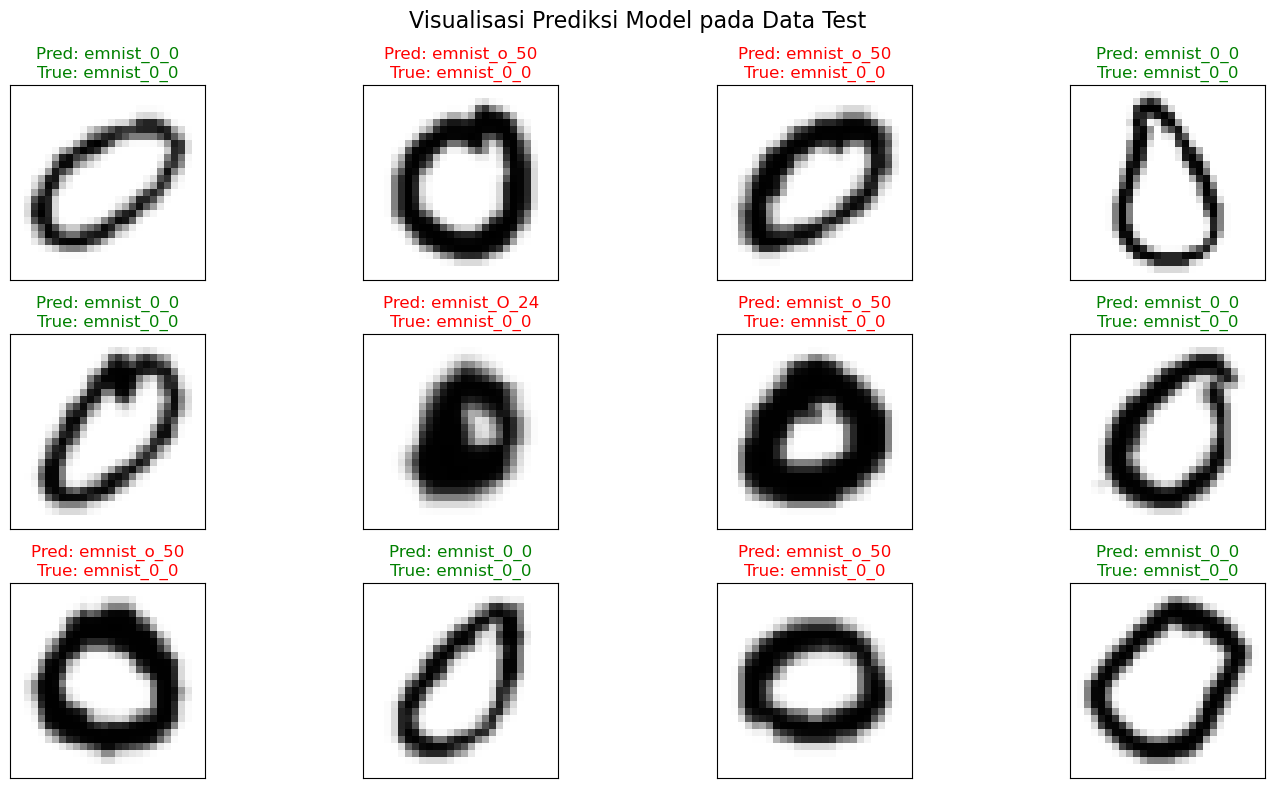

In [9]:
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,   num_workers=NUM_WORKERS)
# =============================================================================
# STEP 12: Evaluasi Model & Visualisasi Prediksi Data Test
# =============================================================================
import torch
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report
from tqdm import tqdm

print("\n[12] Memulai Evaluasi pada Data Test...")

# 1. LOAD MODEL TERBAIK
# Kita pastikan mengambil model dengan akurasi Validasi tertinggi dari file .pth
checkpoint_path = os.path.join(CHECKPOINT_DIR, 'best_model.pth')
if not os.path.exists(checkpoint_path):
    raise FileNotFoundError("Checkpoint model tidak ditemukan. Pastikan proses Training sudah selesai dan berhasil save model.")

checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
saved_class_names = checkpoint['class_names'] # Ambil nama kelas untuk memastikan urutannya benar
model.to(device)
model.eval() # PENTING: Set ke mode evaluasi (matikan dropout)

print(f"✅ Model terbaik berhasil di-load!")
print(f"   - Dari Epoch      : {checkpoint['epoch'] + 1}")
print(f"   - Val Acc Terbaik : {checkpoint['val_acc']:.2f}%")

# 2. LOOP PREDIKSI DATA TEST
all_preds = []
all_labels = []

print("\n🚀 Memproses prediksi data test...")
with torch.no_grad(): # Matikan perhitungan gradien agar cepat dan hemat RAM
    test_bar = tqdm(test_loader, desc="Testing")
    for images, labels in test_bar:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass (Tebak gambar)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
        # Simpan hasil untuk dievaluasi nanti
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 3. HITUNG METRIK EVALUASI
test_acc = accuracy_score(all_labels, all_preds)
print("\n" + "="*40)
print(f"🏆 HASIL UJIAN AKHIR (TEST ACCURACY): {test_acc * 100:.2f}%")
print("="*40)

# Tampilkan Classification Report (Precision, Recall, F1-Score)
# Karena ada 134 kelas, outputnya akan panjang. Anda bisa scroll di hasil outputnya.
print("\n📊 Detail Classification Report:")
report = classification_report(all_labels, all_preds, target_names=saved_class_names, zero_division=0)
print(report)


# 4. VISUALISASI PREDIKSI (MARI KITA LIHAT MODEL BEKERJA!)
def imshow_unnormalized(img):
    """Fungsi untuk mengembalikan gambar yang ternormalisasi (-1 s/d 1) menjadi (0 s/d 1) untuk ditampilkan"""
    img = img * 0.5 + 0.5     # Un-normalize
    npimg = img.numpy()
    plt.imshow(np.squeeze(npimg), cmap='gray')

# Ambil 1 batch secara acak dari test_loader
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Prediksi 1 batch tersebut
images_dev = images.to(device)
with torch.no_grad():
    outputs = model(images_dev)
    _, predicted = torch.max(outputs, 1)

# Tampilkan 12 gambar pertama dari batch beserta tebakannya
fig = plt.figure(figsize=(15, 8))
fig.suptitle("Visualisasi Prediksi Model pada Data Test", fontsize=16)

for idx in np.arange(12):
    ax = fig.add_subplot(3, 4, idx+1, xticks=[], yticks=[])
    imshow_unnormalized(images[idx])
    
    # Cek apakah tebakannya benar
    true_label = saved_class_names[labels[idx].item()]
    pred_label = saved_class_names[predicted[idx].item()]
    
    color = "green" if pred_label == true_label else "red"
    ax.set_title(f"Pred: {pred_label}\nTrue: {true_label}", color=color, fontsize=12)

plt.tight_layout()
plt.show()

In [12]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(all_labels, all_preds))

[[496   0   0 ...   0   0   0]
 [  0 611   2 ...   0   0   0]
 [  0   0 635 ...   0   0   0]
 ...
 [  0   0   0 ... 730   0   0]
 [  0   0   0 ...   0 696  29]
 [  0   0   0 ...   0   3 731]]


⏳ Memuat model dari harddisk...
✅ Model berhasil diload! (Trained Val Accuracy: 88.07%)

🔍 Ditemukan 33 gambar. Memulai prediksi...



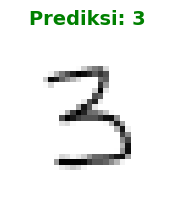

🎯 File: '3.jpg' -> Prediksi: 3 (Yakin: 98.89%)
----------------------------------------


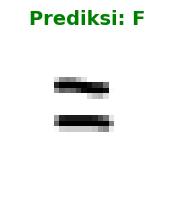

🎯 File: '=.jpg' -> Prediksi: F (Yakin: 70.28%)
----------------------------------------


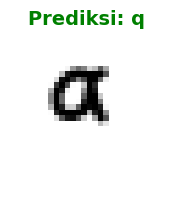

🎯 File: 'alpha.jpg' -> Prediksi: q (Yakin: 48.91%)
----------------------------------------


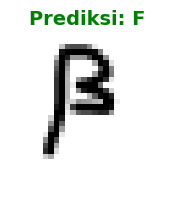

🎯 File: 'beta.jpg' -> Prediksi: F (Yakin: 45.88%)
----------------------------------------


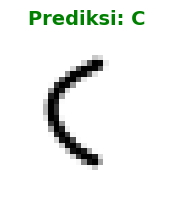

🎯 File: 'closingBrakets.jpg' -> Prediksi: C (Yakin: 94.02%)
----------------------------------------


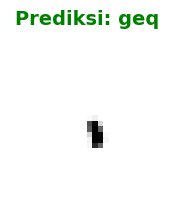

🎯 File: 'coma.jpg' -> Prediksi: geq (Yakin: 77.85%)
----------------------------------------


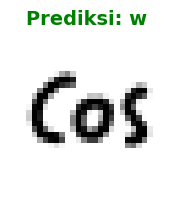

🎯 File: 'cos.jpg' -> Prediksi: w (Yakin: 66.61%)
----------------------------------------


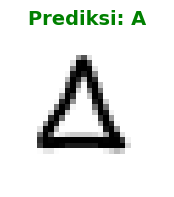

🎯 File: 'delta.jpg' -> Prediksi: A (Yakin: 48.64%)
----------------------------------------


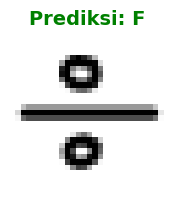

🎯 File: 'div.jpg' -> Prediksi: F (Yakin: 37.47%)
----------------------------------------


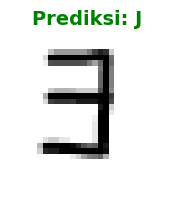

🎯 File: 'exist.jpg' -> Prediksi: J (Yakin: 43.35%)
----------------------------------------


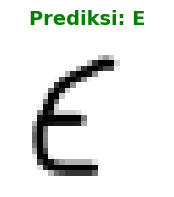

🎯 File: 'exp.jpg' -> Prediksi: E (Yakin: 99.76%)
----------------------------------------


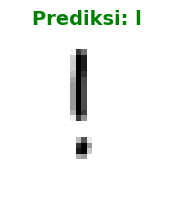

🎯 File: 'faktorial.jpg' -> Prediksi: l (Yakin: 45.14%)
----------------------------------------


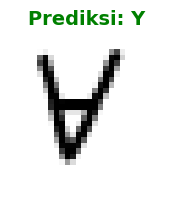

🎯 File: 'forall.jpg' -> Prediksi: Y (Yakin: 52.35%)
----------------------------------------


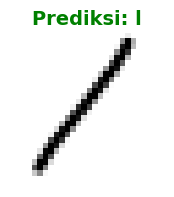

🎯 File: 'forwarSlash.jpg' -> Prediksi: l (Yakin: 53.79%)
----------------------------------------


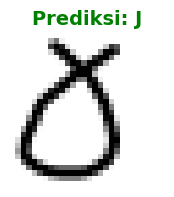

🎯 File: 'gamma.jpg' -> Prediksi: J (Yakin: 99.81%)
----------------------------------------


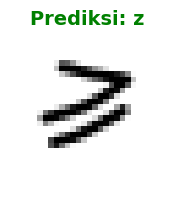

🎯 File: 'geq.jpg' -> Prediksi: z (Yakin: 67.31%)
----------------------------------------


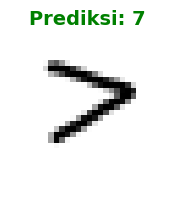

🎯 File: 'gt.jpg' -> Prediksi: 7 (Yakin: 82.16%)
----------------------------------------


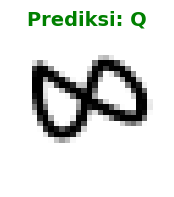

🎯 File: 'inf.jpg' -> Prediksi: Q (Yakin: 35.15%)
----------------------------------------


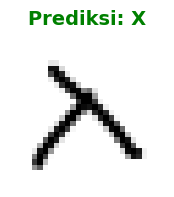

🎯 File: 'lambda.jpg' -> Prediksi: X (Yakin: 93.33%)
----------------------------------------


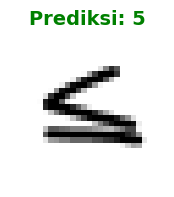

🎯 File: 'leq.jpg' -> Prediksi: 5 (Yakin: 48.33%)
----------------------------------------


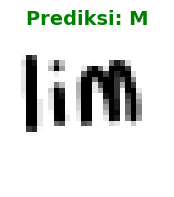

🎯 File: 'lim.jpg' -> Prediksi: M (Yakin: 69.01%)
----------------------------------------


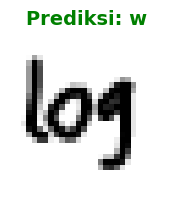

🎯 File: 'log.jpg' -> Prediksi: w (Yakin: 46.03%)
----------------------------------------


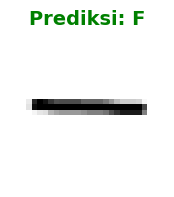

🎯 File: 'negative.jpg' -> Prediksi: F (Yakin: 33.34%)
----------------------------------------


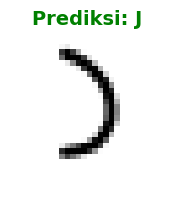

🎯 File: 'openBrakets.jpg' -> Prediksi: J (Yakin: 51.24%)
----------------------------------------


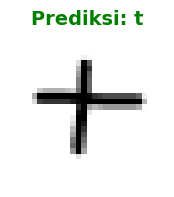

🎯 File: 'plus.jpg' -> Prediksi: t (Yakin: 96.28%)
----------------------------------------


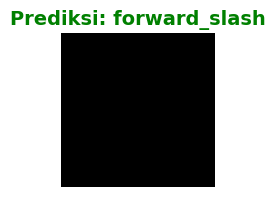

🎯 File: 'sigma.jpg' -> Prediksi: forward_slash (Yakin: 36.17%)
----------------------------------------


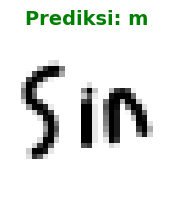

🎯 File: 'sin.jpg' -> Prediksi: m (Yakin: 59.01%)
----------------------------------------


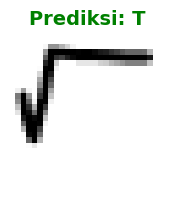

🎯 File: 'sqrt.jpg' -> Prediksi: T (Yakin: 69.82%)
----------------------------------------


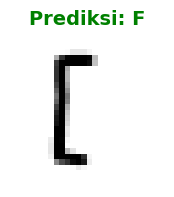

🎯 File: '[.jpg' -> Prediksi: F (Yakin: 20.23%)
----------------------------------------


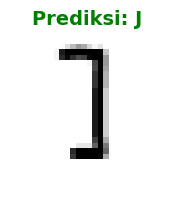

🎯 File: '].jpg' -> Prediksi: J (Yakin: 64.02%)
----------------------------------------


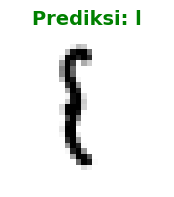

🎯 File: '{.jpg' -> Prediksi: l (Yakin: 30.72%)
----------------------------------------


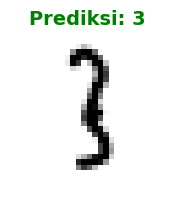

🎯 File: '}.jpg' -> Prediksi: 3 (Yakin: 89.88%)
----------------------------------------


In [1]:
# =============================================================================
# UJI COBA MODEL: LOOPING FOLDER TULISAN TANGAN (NAMA KELAS BERSIH)
# =============================================================================
import os
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt

# --- KONFIGURASI PATH ---
TEST_FOLDER = r'C:\Users\LENOVO\tubesAILab\mathSymbolsTest'
CHECKPOINT_PATH = r'C:\Users\LENOVO\tubesAILab\best_model.pth'
# ------------------------

# Pakai CPU
device = torch.device("cpu")

# 1. DEFINISI ARSITEKTUR MODEL
class Net(nn.Module):
    def __init__(self, num_classes):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2, padding=1)
        self.fc1 = nn.Linear(128 * 4 * 4, 512)
        self.dropout = nn.Dropout(0.4)
        self.fc2 = nn.Linear(512, num_classes)
        
    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        x = x.view(-1, 128 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# 2. LOAD MODEL DAN NAMA KELAS
if not os.path.exists(CHECKPOINT_PATH):
    raise FileNotFoundError(f"File model tidak ditemukan di: {CHECKPOINT_PATH}")

print("⏳ Memuat model dari harddisk...")
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
saved_class_names = checkpoint['class_names']
num_classes = len(saved_class_names)

model = Net(num_classes=num_classes).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval() 

print(f"✅ Model berhasil diload! (Trained Val Accuracy: {checkpoint.get('val_acc', 0):.2f}%)\n")

# 3. LOOPING MEMBACA GAMBAR
valid_extensions = ('.png', '.jpg', '.jpeg')
try:
    image_files = [f for f in os.listdir(TEST_FOLDER) if f.lower().endswith(valid_extensions)]
except FileNotFoundError:
    print(f"❌ Folder tidak ditemukan: {TEST_FOLDER}")
    image_files = []

if not image_files:
    print(f"⚠️ Tidak ada file gambar (.png, .jpg) di dalam folder {TEST_FOLDER}")
else:
    print(f"🔍 Ditemukan {len(image_files)} gambar. Memulai prediksi...\n")
    
    for filename in image_files:
        image_path = os.path.join(TEST_FOLDER, filename)
        
        # Baca Gambar (Grayscale)
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
            
        # Preprocessing (Otsu Threshold)
        _, img_thresh = cv2.threshold(img, 128, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
        
        # Invert (Teks harus hitam, background putih)
        if img_thresh[0, 0] < 127: 
            img_thresh = 255 - img_thresh

        # Resize ke 28x28
        img_resized = cv2.resize(img_thresh, (28, 28), interpolation=cv2.INTER_AREA)
        
        # Convert ke Tensor
        transform = transforms.Compose([
            transforms.ToTensor(),               
            transforms.Normalize((0.5,), (0.5,)) 
        ])
        
        img_tensor = transform(Image.fromarray(img_resized)).unsqueeze(0).to(device)
        
        # Prediksi HANYA TOP 1
        with torch.no_grad():
            output = model(img_tensor)
            probabilities = torch.nn.functional.softmax(output, dim=1)[0]
            top1_prob, top1_idx = torch.topk(probabilities, 1) 
            
        # =================================================================
        # PERBAIKAN: EKSTRAK LABEL BERSIH
        # =================================================================
        raw_pred = saved_class_names[top1_idx[0].item()]
        
        # Memecah string berdasarkan '_'. Contoh: "emnist_A_10" -> ["emnist", "A", "10"]
        parts = raw_pred.split('_')
        
        # Mengambil bagian tengahnya saja (mendukung label yang punya '_' juga, seperti 'forward_slash')
        clean_pred = "_".join(parts[1:-1]) 
        
        best_prob = top1_prob[0].item() * 100
        # =================================================================
        
        # Tampilkan Gambar + Judul Tebakan
        plt.figure(figsize=(2, 2))
        plt.imshow(img_resized, cmap='gray')
        plt.title(f"Prediksi: {clean_pred}", fontsize=14, color='green', fontweight='bold')
        plt.axis('off')
        plt.show()
        
        # Tampilkan Teks Kesimpulan
        print(f"🎯 File: '{filename}' -> Prediksi: {clean_pred} (Yakin: {best_prob:.2f}%)")
        print("-" * 40)